In [34]:
# load settings
import copy
import re
import typing as t
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from scipy.optimize import curve_fit
import numpy as np
from scipy.interpolate import interp1d

np.random.seed(42)  # For reproducibility
data_root = Path("/Users/jliu/workspace/lexical_bencmark/dataset")
fig_path = Path(data_root / "fig")
y_label_dict = {"rej_type_rate": "non-word rate", "type_token_ratio": "ttr", "CDI": "CDI", "slope": "slope"}

# plotting style configuration and data loading



In [35]:
# Type aliases
DataFrameType = pd.DataFrame
PathType = Path | str


class PlotSettings:
    """Unified plotting settings and styling configuration."""

    COLORS: dict[str, str] = {"human_CDI": "#d62728", "CHILDES": "orange", "stela": "blue", "child": "green", 0.3: "purple", 0.6: "darkblue", 1.0: "grey", 1.5: "black"}

    LINESTYLES: dict[str, str] = {"CHILDES": "-", "child": "-", "LSTM": "-", "trans": "-."}

    DEFAULTS: dict[str, t.Any] = {
        "label_fontsize": 22,
        "linewidth": 3.5,
        "title_fontsize": 28,
        "grid_color": "#bbbbbb",
        "figsize": (8, 6),
        "default_fill_alpha": 0.25,
        "capsize": 3,
        "capthick": 3,
        "elinewidth": 3,
    }

    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.5,
    }

    @staticmethod
    def configure_plot(title: str | None = None, model: str | None = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=PlotSettings.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])

    @staticmethod
    def configure_legend() -> None:
        """Configure legend settings."""
        plt.legend(
            title="Settings", title_fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontsize=PlotSettings.DEFAULTS["label_fontsize"], loc="upper left", bbox_to_anchor=(1.01, 1)
        )

    @staticmethod
    def configure_legend(outside: bool = True) -> None:
        """Configure legend settings."""
        legend_params = {
            "title": "Settings",
            "title_fontsize": PlotSettings.DEFAULTS["title_fontsize"],
            "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        }
        if outside:
            legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
        else:
            legend_params.update(
                {
                    "loc": "best"  # Matplotlib will automatically find best location
                }
            )

        plt.legend(**legend_params)

    @staticmethod
    def save_figure(filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @staticmethod
    def get_color_palette(n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette(n_colors=n_colors).as_hex()

    @staticmethod
    def apply_style_to_axis(ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=PlotSettings.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])


def extract_style(text: str) -> str:
    """Extract text inside parentheses."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""


def configure_plot_style(
    x_label: str,
    y_label: str,
    fig_title: str | None = None,
    legend_title: str | None = None,
    grid: bool = True,
    out_path: Path | None = None,
    ylim: tuple | None = None,
    y_decimal: int | None = None,
    show_legend: bool = True,
    legend_outside: bool = True,
    save_legend: bool = False,
) -> None:
    """Configure plot styling."""
    plt.grid(grid, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(x_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if fig_title:
        plt.title(fig_title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontweight="bold", pad=20)

    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    # Configure legend parameters
    legend_params = {
        "title": legend_title,
        "title_fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "framealpha": 0.9,
        "edgecolor": "black",
    }

    if legend_outside:
        legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
    else:
        legend_params.update({"loc": "best"})

    # Always create legend first for potential saving
    legend = plt.legend(**legend_params)

    # Save legend if requested
    if save_legend and out_path:
        fig_legend = plt.figure(figsize=(3, 2))
        ax = fig_legend.add_subplot(111)
        ax.axis("off")
        ax.legend(legend.legendHandles, [t.get_text() for t in legend.get_texts()], title=legend.get_title().get_text(), loc="center")
        legend_path = out_path.parent / f"{out_path.stem}_legend{out_path.suffix}"
        print(legend_path)
        fig_legend.savefig(legend_path, bbox_inches="tight", dpi=300)
        plt.close(fig_legend)

    # Remove legend if not showing
    if not show_legend:
        legend.remove()

    if y_decimal:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter(f"%.{y_decimal}f"))

    plt.tight_layout()
    plt.ylim(ylim)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()

In [20]:
class DataLoader:
    """Unified data loading and preprocessing functionality."""

    @staticmethod
    def get_freq(df: DataFrameType) -> DataFrameType:
        """Annotate frequency of the given column."""
        df = df.copy()
        if "freq" not in df.columns:
            df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
        df["log_freq"] = np.log10(df["freq"] + 1e-10)
        return df.dropna()

    @staticmethod
    def load_df(df: DataFrameType, metric: str, temp: float | None = None) -> DataFrameType:
        """Load and aggregate data based on metric while handling duplicates."""
        df = df.copy()
        # Filter the given temperature
        if temp:
            df = df[df["temp"] == temp].copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
        # results on the aggregated month
        if metric != "CDI":
            df[metric] = df[metric].fillna(method="ffill")
            df = (
                df.groupby(["condition", metric])
                .agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"})
                .reset_index()
            )
        return df

    @staticmethod
    def load_temp_df(df: DataFrameType, x_header: str, y_header: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
        if y_header == "slope":
            # Group by condition and calculate slope
            df_all = df.copy()
            df = pd.DataFrame()
            df_grouped = df_all.groupby(["temp", "chunk"])
            for _, group in df_grouped:
                slope = (group["CDI"].iloc[-1] - group["CDI"].iloc[0]) * 100 / len(group)
                group["slope"] = slope
                df = pd.concat([df, group])
            print(df.head(10))
        # Calculate means across months for each condition and temperature
        grouped_df = df.groupby(["condition", "temp"]).agg({x_header: "mean", y_header: "mean"}).reset_index()

        return grouped_df

    @staticmethod
    def load_sigmoid_df(df: DataFrameType, metric: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        df = df.copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
        df[metric] = df[metric].fillna(method="ffill")
        df = df.groupby(["condition", "temp"]).reset_index()
        return df

    @staticmethod
    def calculate_statistics(df: DataFrameType, group_header: list, x_header: str, y_header: str | None = None) -> DataFrameType:
        """Calculate mean, standard deviation, and confidence intervals of the grouped df."""
        # safe copy
        df = df.copy()
        group_header_lst = copy.deepcopy(group_header)
        group_header_lst.append(x_header)
        if y_header:
            stats = df.groupby(group_header_lst)[y_header].agg(["mean", "std", "count", "min", "max"]).reset_index()
        else:
            stats = df.groupby(group_header_lst).agg(["mean", "std", "count", "min", "max"]).reset_index()
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats

    @staticmethod
    def calculate_threshold_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
        # Group by x_col and calculate statistics
        stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
        # Calculate 95% confidence interval
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats

# plotting functions

In [75]:
import wandb

# Initialize API
api = wandb.Api()

color_dict: dict[str, str] = {60: "blue", 2:"green" }

linestyle_dict: dict[str, str] = {"lstm": "-", "gpt2": "-."}   #ignore


In [100]:
# Get a specific run
def get_loss(run_id:str)->pd.DataFrame:
    """Get loss from wandb api"""
    # Initialize API
    api = wandb.Api()
    # get the target sun
    run = api.run(run_id)
    # Get the history (all logged metrics)
    history = run.history()
    # Extract loss columns
    train_loss = history['train/loss']  # or whatever your loss key is
    val_loss = history['eval/loss']
    steps = history['train/global_step']
    # Convert to pandas DataFrame for easier manipulation
    return pd.DataFrame({
        'step': steps,
        'train_loss': train_loss,
        'val_loss': val_loss
    })

def count_data(seq_length:int,training_steps:int,batch_size:int)->int:
    """Recover data quantity from the training steps. """
    return training_steps * batch_size * seq_length 


def gather_data_seen(
    id_dict:dict,batch_dict:dict,seq_length=1024,plot_fig=True,color_dict:dict|None=None,linestyle_dict:dict|None=None)->dict:
    """Store loss info into dict"""
    
    # loop the id_dict
    loss_dict = {}
    for model_type,jobs in id_dict.items():
        batch_size= batch_dict[model_type]
        loss_dict[model_type] = {}
        for chunk, run_id in jobs.items():
            loss_df = get_loss(run_id)
            loss_df['data_seen'] = loss_df['step'].apply(
                lambda steps: count_data(seq_length=seq_length, training_steps=steps, batch_size=batch_size)
            )
            loss_dict[model_type][chunk] = loss_df
            if plot_fig:
                x_list = loss_df["data_seen"] / 1_000_000
                plot_progress(loss_df,x_list,"train_loss",color_dict[model_type],linestyle_dict["train_loss"],label = f"{model_type}_train")
                plot_progress(loss_df,x_list,"val_loss",color_dict[model_type],linestyle_dict["val_loss"],label = f"{model_type}_val")
    plt.legend()
    plt.xlabel("Data_seen (per million characters)")
    plt.ylabel("Loss")
    plt.ylim([0.5,4])
    return loss_dict


def plot_progress(loss_df,x_list,y_header,color,linestyle,label):
    # Create interpolation function
    x = x_list
    y = loss_df[y_header]

    # Remove any NaN values first
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Create interpolation function
    f_linear = interp1d(x_clean, y_clean, kind='linear')

    # Generate smooth x values
    x_smooth = np.linspace(x_clean.min(), x_clean.max(), 300)
    y_smooth = f_linear(x_smooth)

    plt.plot(x_smooth, y_smooth,color=color,linestyle=linestyle,label=label)
    





In [111]:
12_000_000_000 / 8 / 1_000_0000

150.0

In [113]:
41/6

6.833333333333333

{'lstm': {60:        step  train_loss  val_loss    data_seen
  0       100      4.7100       NaN     13107200
  1       500      2.6763       NaN     65536000
  2       600      2.3818       NaN     78643200
  3       900      1.9641       NaN    117964800
  4      1000         NaN  1.862121    131072000
  ..      ...         ...       ...          ...
  495   99300      1.0089       NaN  13015449600
  496   99400      1.0070       NaN  13028556800
  497   99700      1.0084       NaN  13067878400
  498   99800      1.0062       NaN  13080985600
  499  100000         NaN       NaN  13107200000
  
  [500 rows x 4 columns]},
 'gpt2': {60:       step  train_loss  val_loss   data_seen
  0      100      3.0623       NaN    13107200
  1      200      2.4675       NaN    26214400
  2      400      2.3820       NaN    52428800
  3      500      2.3651       NaN    65536000
  4      600      2.3391       NaN    78643200
  ..     ...         ...       ...         ...
  495  69600      0.8790     

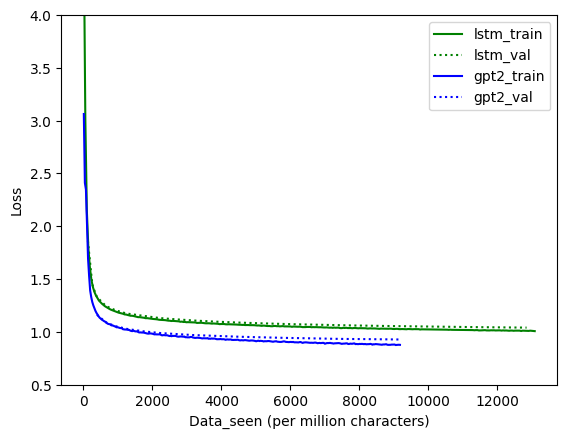

In [110]:
# plot model differences
color_dict: dict[str, str] = {"lstm": "green", "gpt2": "blue"} 
linestyle_dict: dict[str, str] = {"train_loss": "-", "val_loss": ":"} 

id_dict = { "lstm":{60:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/runs/51yx4xrl"},
    "gpt2":{60:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/b4sc8jtr"},
}
batch_dict = {"lstm":128, "gpt2":128}
gather_data_seen(id_dict,batch_dict,plot_fig=True,color_dict=color_dict,linestyle_dict=linestyle_dict)

{'lstm': {40:        step  train_loss  val_loss   data_seen
  0       200      3.9892       NaN    13107200
  1       400      2.9804       NaN    26214400
  2       500      2.9508       NaN    32768000
  3       900      2.9349       NaN    58982400
  4      1000      2.9335       NaN    65536000
  ..      ...         ...       ...         ...
  495   99100      1.0897       NaN  6494617600
  496   99500      1.0884       NaN  6520832000
  497   99700      1.0903       NaN  6533939200
  498   99800      1.0920       NaN  6540492800
  499  100000         NaN       NaN  6553600000
  
  [500 rows x 4 columns]},
 'gpt2': {40:       step  train_loss  val_loss   data_seen
  0      100      3.0813       NaN     6553600
  1      200      2.4662       NaN    13107200
  2      400      2.3787       NaN    26214400
  3      600      2.3359       NaN    39321600
  4      700      2.2392       NaN    45875200
  ..     ...         ...       ...         ...
  495  53800      0.8647       NaN  35258

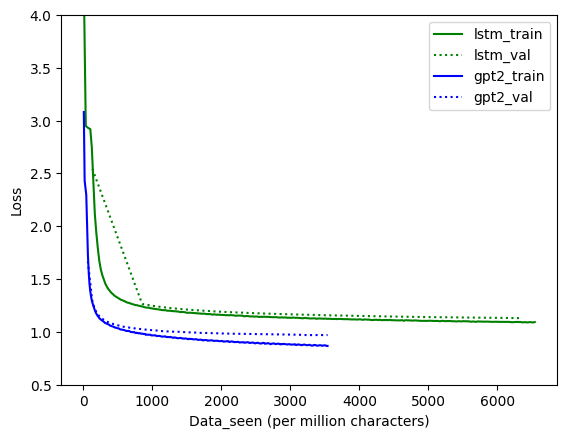

In [108]:
# plot model differences
color_dict: dict[str, str] = {"lstm": "green", "gpt2": "blue"} 
linestyle_dict: dict[str, str] = {"train_loss": "-", "val_loss": ":"} 

id_dict = { "lstm":{40:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/fy6q9fo3"},
    "gpt2":{40:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/5tm3wxay"},
}
batch_dict = {"lstm":64, "gpt2":64}
gather_data_seen(id_dict,batch_dict,plot_fig=True,color_dict=color_dict,linestyle_dict=linestyle_dict)

{'lstm': {10:       step  train_loss  val_loss   data_seen
  0      100      4.7291       NaN     3276800
  1      700      2.9305       NaN    22937600
  2     1000         NaN  2.933023    32768000
  3     1300      2.9214       NaN    42598400
  4     1400      2.9133       NaN    45875200
  ..     ...         ...       ...         ...
  495  99000      1.0481       NaN  3244032000
  496  99100      1.0515       NaN  3247308800
  497  99300      1.0475       NaN  3253862400
  498  99700      1.0512       NaN  3266969600
  499  99800      1.0488       NaN  3270246400
  
  [500 rows x 4 columns]},
 'gpt2': {10:     step  train_loss  val_loss   data_seen
  0    100      3.0276       NaN    13107200
  1    200      2.4621       NaN    26214400
  2    300      2.4056       NaN    39321600
  3    400      2.3802       NaN    52428800
  4    500      2.3613       NaN    65536000
  ..   ...         ...       ...         ...
  95  8800      0.9535       NaN  1153433600
  96  8900      0.9499

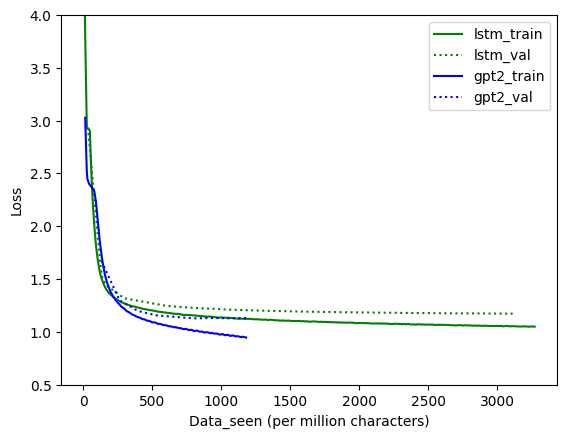

In [103]:
# plot model differences
color_dict: dict[str, str] = {"lstm": "green", "gpt2": "blue"} 
linestyle_dict: dict[str, str] = {"train_loss": "-", "val_loss": ":"} 

id_dict = { "lstm":{10:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/4kv9rqnc"},
    "gpt2":{10:"ecnucrystal-cole-normale-sup-rieure/Lexical-Benchmark/g4r6qyox"},
}
batch_dict = {"lstm":32, "gpt2":128}
gather_data_seen(id_dict,batch_dict,plot_fig=True,color_dict=color_dict,linestyle_dict=linestyle_dict)

In [24]:
loss_df

,step,train_loss,val_loss,data_seen
0,200,3.3428,NaN,26214400
1,300,2.9483,NaN,39321600
2,500,2.6763,NaN,65536000
3,600,2.3818,NaN,78643200
4,900,1.9641,NaN,117964800
...,...,...,...,...
495,99300,1.0089,NaN,13015449600
496,99500,1.0097,NaN,13041664000
497,99600,1.0095,NaN,13054771200
498,99800,1.0062,NaN,13080985600


In [26]:
loss_df = loss_dict["lstm"][60]

In [ ]:
def plot_data_progress(loss_df,color,linestyle):
    # Create interpolation function
    x = loss_df["data_seen"] / 1_000_000
    y = loss_df["train_loss"]

    # Remove any NaN values first
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]

    # Create interpolation function
    f_linear = interp1d(x_clean, y_clean, kind='linear')
    # Generate smooth x values
    x_smooth = np.linspace(x_clean.min(), x_clean.max(), 300)
    y_smooth = f_linear(x_smooth)
    plt.plot(x_smooth, y_smooth,color=color,linestyle=linestyle)

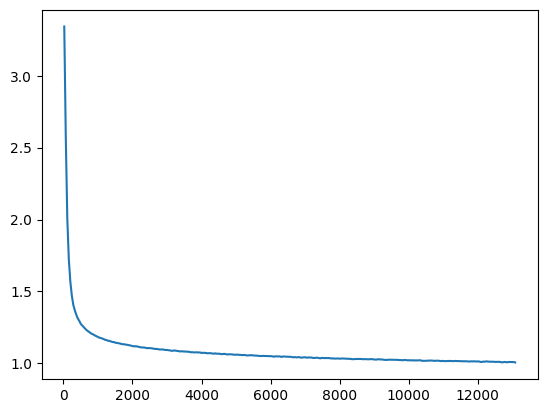

In [32]:
loss_df = loss_dict["lstm"][60]
plot_data_progress(loss_df)

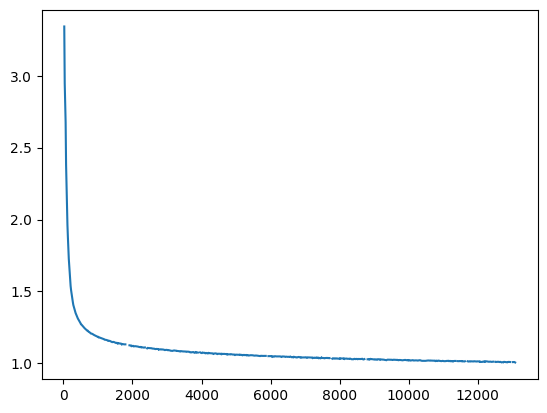

In [29]:
plt.plot(loss_df["data_seen"]/1_000_000,loss_df["train_loss"])

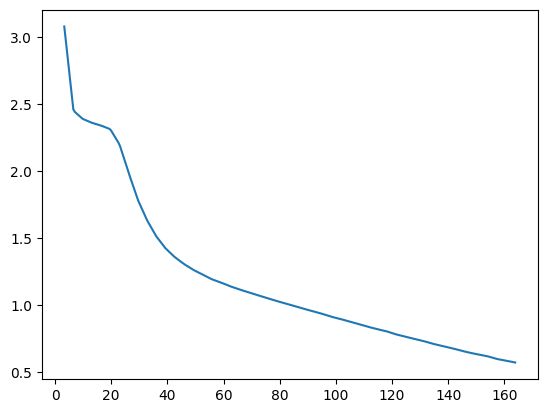

In [33]:
loss_df = loss_dict["gpt2"][2]
plot_data_progress(loss_df)

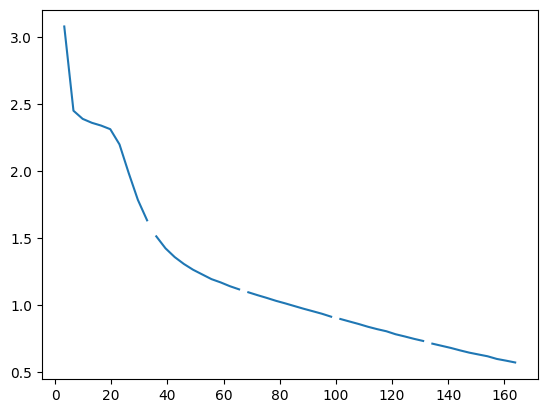

In [30]:
loss_df = loss_dict["gpt2"][2]
plt.plot(loss_df["data_seen"]/1_000_000,loss_df["train_loss"])

In [20]:
loss_dict["gpt2"][2]

,step,train_loss,val_loss,data_seen
0,100,3.0783,NaN,3276800
1,200,2.4499,NaN,6553600
2,300,2.3892,NaN,9830400
3,400,2.3598,NaN,13107200
4,500,2.3392,NaN,16384000
5,600,2.3122,NaN,19660800
6,700,2.1988,NaN,22937600
7,800,1.9855,NaN,26214400
8,900,1.7848,NaN,29491200
9,1000,1.6324,NaN,32768000


In [38]:
def configure_plot_style(
    x_label: str,
    y_label: str,
    fig_title: str | None = None,
    legend_title: str | None = None,
    grid: bool = True,
    out_path: Path | None = None,
    ylim: tuple | None = None,
    y_decimal: int | None = None,
    show_legend: bool = True,
    legend_outside: bool = True,
    save_legend: bool = False,
) -> None:
    """Configure plot styling."""
    plt.grid(grid, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(x_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if fig_title:
        plt.title(fig_title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontweight="bold", pad=20)

    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    # Configure legend parameters
    legend_params = {
        "title": legend_title,
        "title_fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "fontsize": PlotSettings.DEFAULTS["label_fontsize"],
        "framealpha": 0.9,
        "edgecolor": "black",
    }

    if legend_outside:
        legend_params.update({"loc": "upper left", "bbox_to_anchor": (1.01, 1)})
    else:
        legend_params.update({"loc": "best"})

    # Always create legend first for potential saving
    legend = plt.legend(**legend_params)

    # Save legend if requested
    if save_legend and out_path:
        fig_legend = plt.figure(figsize=(3, 2))
        ax = fig_legend.add_subplot(111)
        ax.axis("off")
        ax.legend(legend.legendHandles, [t.get_text() for t in legend.get_texts()], title=legend.get_title().get_text(), loc="center")
        legend_path = out_path.parent / f"{out_path.stem}_legend{out_path.suffix}"
        print(legend_path)
        fig_legend.savefig(legend_path, bbox_inches="tight", dpi=300)
        plt.close(fig_legend)

    # Remove legend if not showing
    if not show_legend:
        legend.remove()

    if y_decimal:
        plt.gca().yaxis.set_major_formatter(FormatStrFormatter(f"%.{y_decimal}f"))

    plt.tight_layout()
    plt.ylim(ylim)

    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)

    plt.show()

# vocalization estimation

# Freq match

In [39]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    out_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    bin_header: str | None = None,
    fig_title: str | None = None,
    legend_outside: bool = False,
    save_legend: bool = False,
    show_legend: bool = True,
) -> None:
    """Plot distributions of a specific column from multiple dataframes."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])
    match_dict = {"alpha": {"matched": 0.2, "unmatched": 0.7, "CDI": 0.2}, "color": {"matched": "blue", "unmatched": "blue", "CDI": "orange"}}
    for name, df in dataframes.items():
        # if name.split("_")[1]:
        if "_" in name:
            color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
            fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])
        else:
            fill_alpha = match_dict["alpha"][name]
            color = match_dict["color"][name]
        # plot distribution based on given type
        distr_plotter = DistrPlotter(
            df=df,
            column=column,
            color=color,
            name=name,
            fill_alpha=fill_alpha,
        )
        distr_plotter.plot_distr(kind, bin_header)

    configure_plot_style(
        x_label=column, y_label="Density", fig_title=fig_title, grid=True, out_path=out_path, show_legend=show_legend, save_legend=save_legend, legend_outside=legend_outside
    )


def compare_freq(file_root: Path, freq_root: Path, output_dir: Path | None = None) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets
    childes = DataLoader.get_freq(pd.read_csv(freq_root / "childes_adult.csv"))
    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))
    child_realistic = DataLoader.get_freq(pd.read_csv(freq_root / "childrealistic_bm_60_00.csv"))

    human_cdi = DataLoader.get_freq(pd.read_csv(file_root / "cdi_childes.csv"))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))
    realistic_cdi = DataLoader.get_freq(pd.read_csv(file_root / "human_realistic_matched_cdi.csv"))

    # Create dataframe collections
    before_after_dfs = {
        "CHILDES_before": childes,
        "stela_before": stela,
        "child_before": child_realistic,
        "CHILDES_after": human_cdi,
        "stela_after": stela_cdi,
        "child_after": realistic_cdi,
    }

    matched_dfs = {"CHILDES_after": human_cdi, "stela_after": stela_cdi, "child_after": realistic_cdi}

    # Generate plots
    plt.figure(figsize=[12, 6])
    out_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(
        before_after_dfs,
        column="log_freq",
        bin_header="bin_nb",
        kind="kde",
        fig_title="Before and After Matching",
        out_path=out_path,
        save_legend=False,
        show_legend=False,
        legend_outside=True,
    )
    out_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(
        matched_dfs,
        column="log_freq",
        bin_header="bin_nb",
        kind="hist",
        fig_title="Matched Bin Distributions",
        out_path=out_path,
        save_legend=False,
        show_legend=False,
        legend_outside=True,
    )


def compare_freq_demo(file_root: Path, freq_root: Path, output_dir: Path | None = None) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets

    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))

    human_cdi = DataLoader.get_freq(pd.read_csv(file_root / "cdi_childes.csv"))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))

    # Create dataframe collections
    before_after_dfs = {
        "unmatched": stela,
        "CDI": human_cdi,
        "matched": stela_cdi,
    }

    matched_dfs = {"CDI": human_cdi, "matched": stela_cdi}

    # Generate plots
    plt.figure(figsize=[10, 6])
    out_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(before_after_dfs, column="log_freq", bin_header="bin_nb", kind="kde", out_path=out_path)
    out_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(matched_dfs, column="log_freq", bin_header="bin_nb", kind="hist", out_path=out_path)

In [40]:
def remap_bins(df, n_bins: int = 6) -> pd.DataFrame:
    """Remap bins to exactly n bins by combining old bins."""
    # Store old bin numbers
    df["bin_nb_old"] = df["bin_nb"]
    # Calculate quantiles for new bins
    df["bin_nb"] = pd.qcut(df["freq"], q=n_bins, labels=range(n_bins))
    # sort by the group number
    df = df.sort_values(by="bin_nb", ascending=True)
    # get the corresponding words
    words_lst = []
    df_grouped = df.groupby("bin_nb")
    for bin_nb, df_group in df_grouped:
        words_lst.append(df_group["word"].to_list())
    return df, words_lst

# test CDI thresholds

In [29]:
def plot_thresholds(df_threshold: pd.DataFrame, x_header: str, ax) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]
    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors, strict=False):
        stats = DataLoader.calculate_threshold_stat(df_threshold, x_header, threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats[x_header], stats["mean"], label=f"{threshold_value}", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")
        ax.fill_between(stats[x_header], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)


def plot_human_CDI(df_human: pd.DataFrame, ax):
    # Plot human CDI development
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))
    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="human", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)


def compare_thresholds(human_cdi_path: Path, threshold_path: Path, out_path=None) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=[8, 6])

    # load data
    df_threshold = pd.read_csv(threshold_path)
    df_human = pd.read_csv(human_cdi_path)
    # plot curves
    plot_thresholds(df_threshold, "month", ax)
    plot_human_CDI(df_human, ax)
    # set plot configurations
    configure_plot_style(x_label="month", y_label="CDI score", fig_title="Count threshold comparison", grid=True, out_path=out_path, legend_outside=False)
    plt.tight_layout()

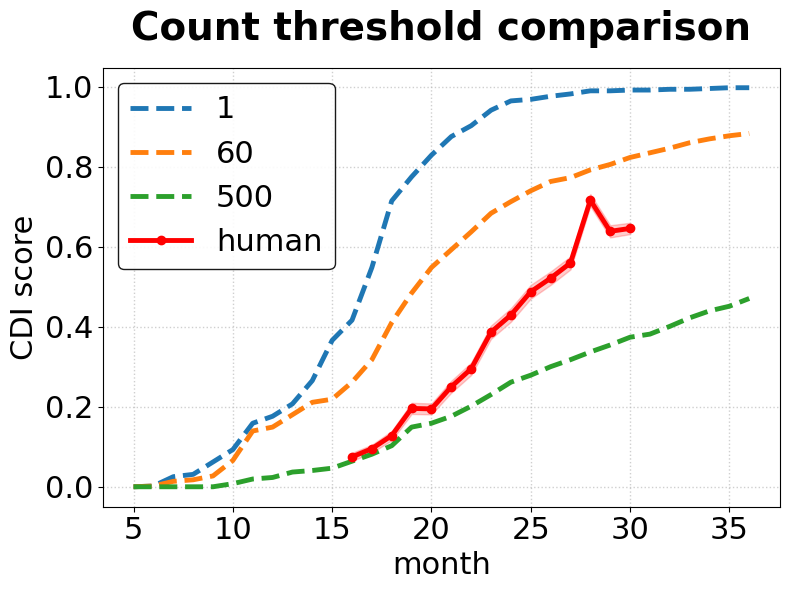

<Figure size 640x480 with 0 Axes>

In [30]:
human_cdi_path = Path(f"{data_root}/matched/EN/1") / "cdi_childes.csv"
threshold_path = data_root / "metric_CDI_threshold_test.csv"
out_path = fig_path / "paper/threshold.pdf"
compare_thresholds(human_cdi_path, threshold_path, out_path)

# Core metrics

In [41]:
def plot_curves(
    df: pd.DataFrame, x_header: str, y_header: str, y_label: str, group_header: str, legend_title: str = None, y_lim: list[float] = [0, 1], out_path: Path | None = None
) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=[8, 6])
    df_stats = DataLoader.calculate_statistics(df, [group_header], x_header, y_header)
    unique_conditions = df_stats[group_header].unique()
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header, y_header="mean")

    configure_plot_style(x_label=x_header, y_label=y_label, grid=True, out_path=out_path, ylim=y_lim, show_legend=True, save_legend=False, legend_outside=False)


def compare_metrics(
    raw_data_path: str,
    out_path: Path,
    suffix: str,
    y_label_dict=y_label_dict,
    metric_dict={"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.5], "rej_token_rate": [0, 0.5], "CDI": [0, 1]},
):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
    for metric, ylim in metric_dict.items():
        y_label = y_label_dict[metric]
        sel_df = DataLoader.load_df(df, metric=metric, temp=1.0)
        (out_path / metric).mkdir(parents=True, exist_ok=True)
        out_path_file = out_path / metric / f"{y_label}_{suffix}.pdf"
        plot_curves(df=sel_df, x_header="month", y_header=metric, y_label=y_label, group_header="condition", y_lim=ylim, out_path=out_path_file)

# Temperature trade-off 

In [42]:
def plot_scatters(df: pd.DataFrame, x_header: str, y_header: str, y_label: str, group_header: str, y_lim: list[float] = [0, 1], out_path: Path | None = None) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=[8, 6])
    df_stats = DataLoader.calculate_statistics(df, [group_header, "temp"], x_header, y_header)
    # save the results to
    unique_conditions = df_stats[group_header].unique()

    for condition in unique_conditions:
        print(condition)
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_scatter(subset, condition, x_header, y_header="mean")
    configure_plot_style(x_label=x_header, y_label=y_label, grid=True, out_path=out_path, ylim=y_lim, show_legend=True, save_legend=True, legend_outside=False)
    return df_stats


def compare_temp(raw_data_path: Path, stat_path: Path, suffix: str, out_path: Path, y_label_dict, metric_dict={"type_token_ratio": [0, 0.6], "rej_type_rate": [0, 0.5]}):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"
    stat_all = pd.DataFrame()
    for metric, ylim in metric_dict.items():
        y_label = y_label_dict[metric]
        sel_df = DataLoader.load_temp_df(df, x_header="CDI", y_header=metric)
        (out_path / metric).mkdir(parents=True, exist_ok=True)
        out_path_file = out_path / metric / f"temp_{y_label}_{suffix}.pdf"
        df_stats = plot_scatters(df=sel_df, x_header="CDI", y_header=metric, y_label=y_label, group_header="condition", y_lim=ylim, out_path=out_path_file)
        df_stats["metric"] = metric
        stat_all = pd.concat([stat_all, df_stats])
    stat_all.to_csv(stat_path)

# Different experiment settings

## 1. Core metrics

##################################################
Current hour 1000; current sampling rate 1


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


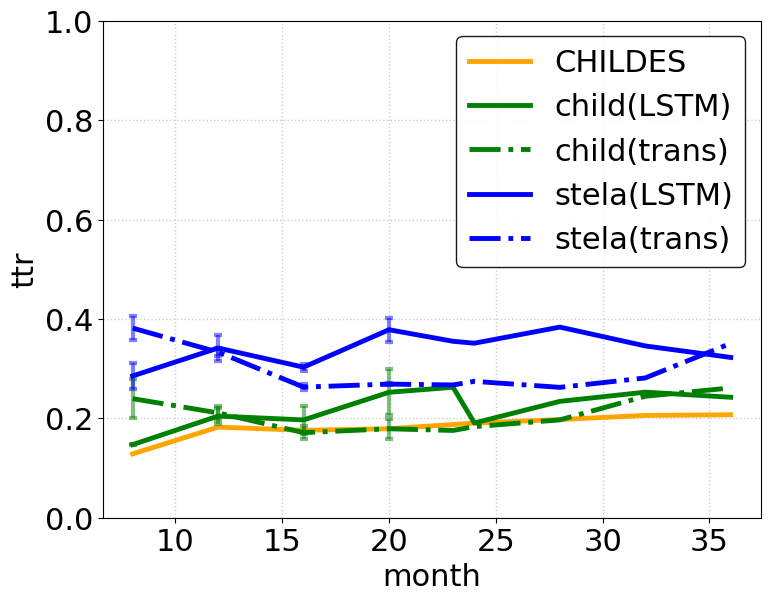

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


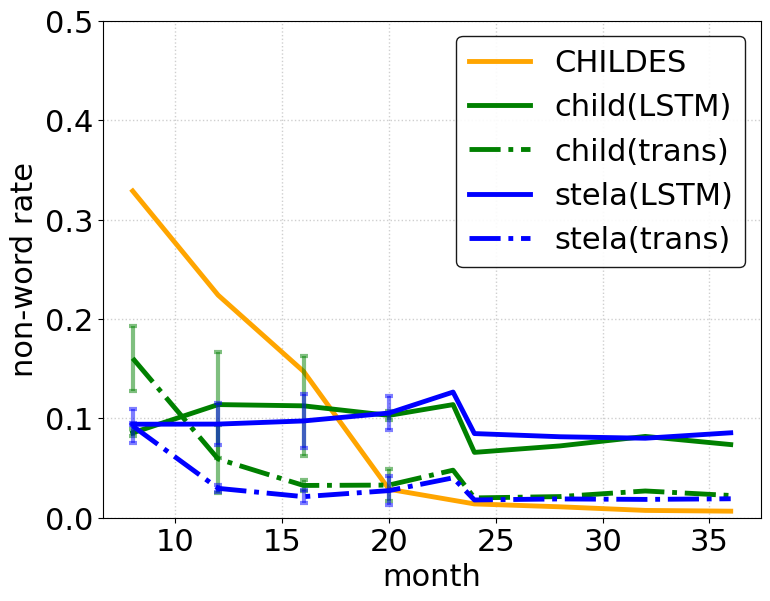

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


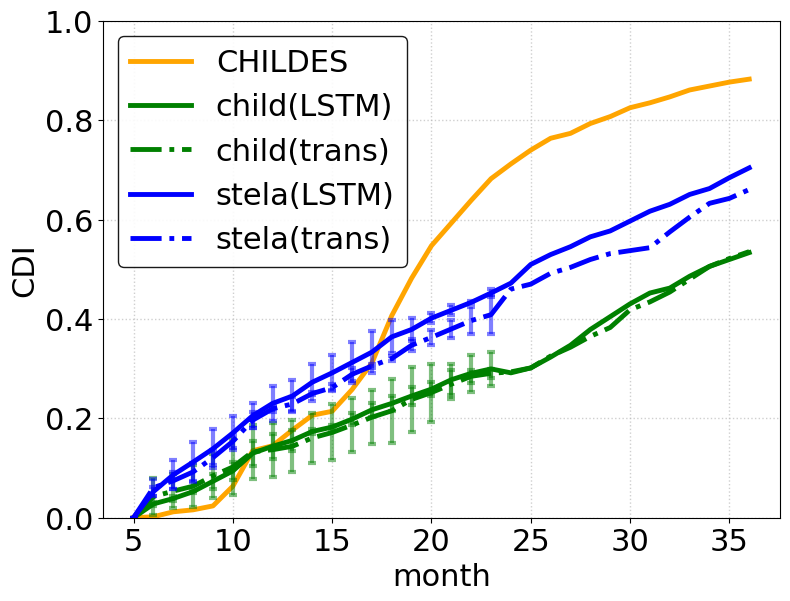

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/type_token_ratio/temp_ttr_1000_1_legend.pdf


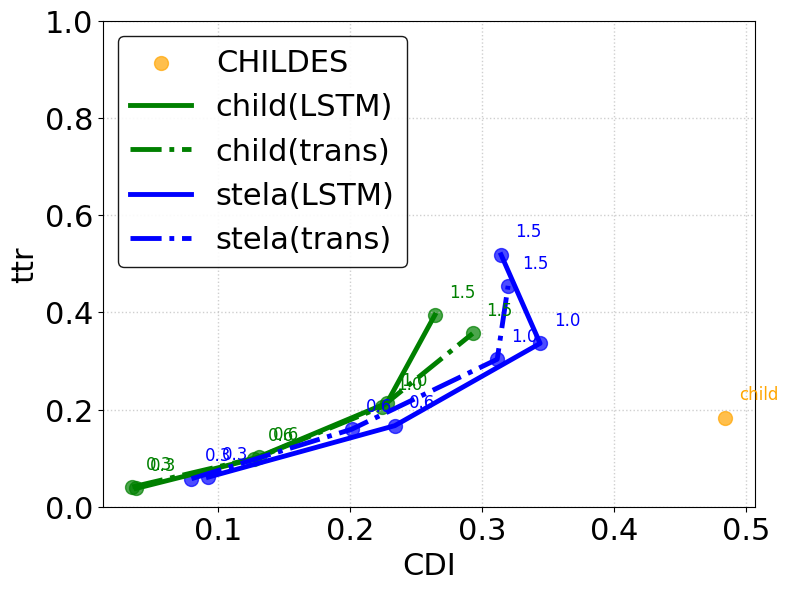

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/rej_type_rate/temp_non-word rate_1000_1_legend.pdf


/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


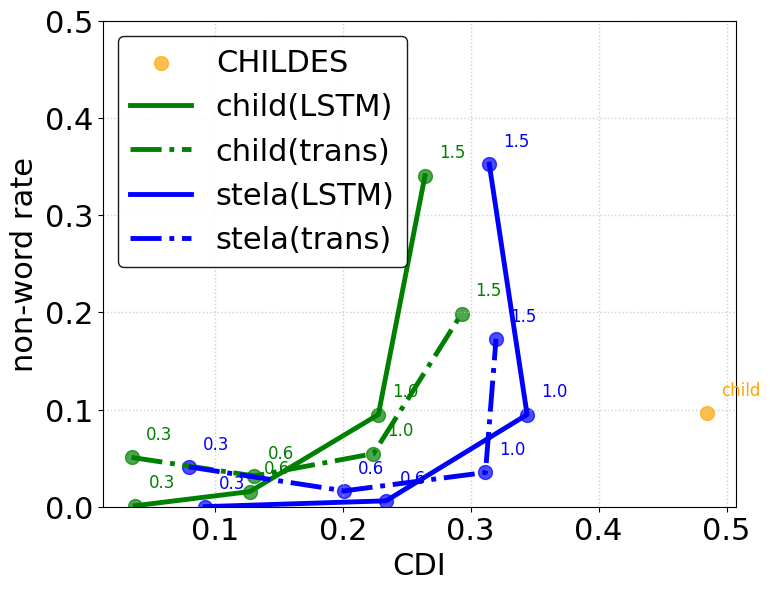

     Unnamed: 0  month  type_token_ratio  rej_type_rate  rej_token_rate  \
32            0      5          0.026857       0.000000           0.000   
36            0      5          0.037143       0.307692           0.014   
440           0      5          0.055143       0.000000           0.000   
444           0      5          0.063714       0.242152           0.020   
52            0      6          0.037143       0.307692           0.014   
48            0      6          0.026857       0.000000           0.000   
460           0      6          0.063714       0.242152           0.020   
456           0      6          0.055143       0.000000           0.000   
472           0      7          0.055143       0.000000           0.000   
476           0      7          0.063714       0.242152           0.020   

          CDI  CDI_0     CDI_1     CDI_2  CDI_3     CDI_4     CDI_5  word_num  \
32   0.000000    0.0  0.000000  0.000000    0.0  0.000000  0.000000       145   
36   0.00000

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


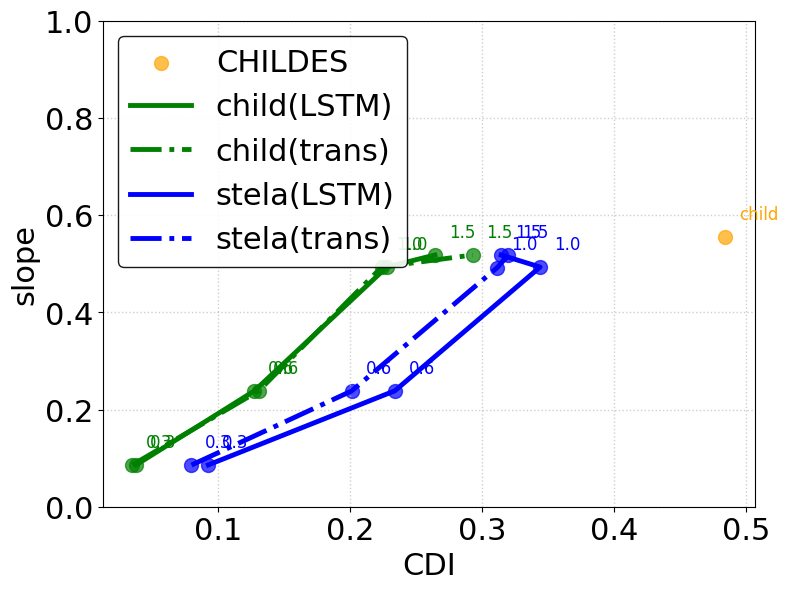

##################################################
Current hour 500; current sampling rate 1


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


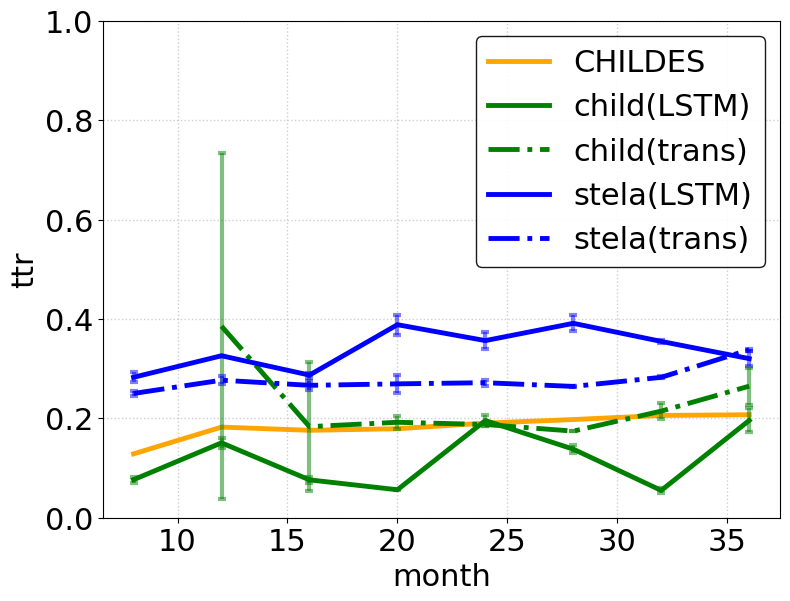

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


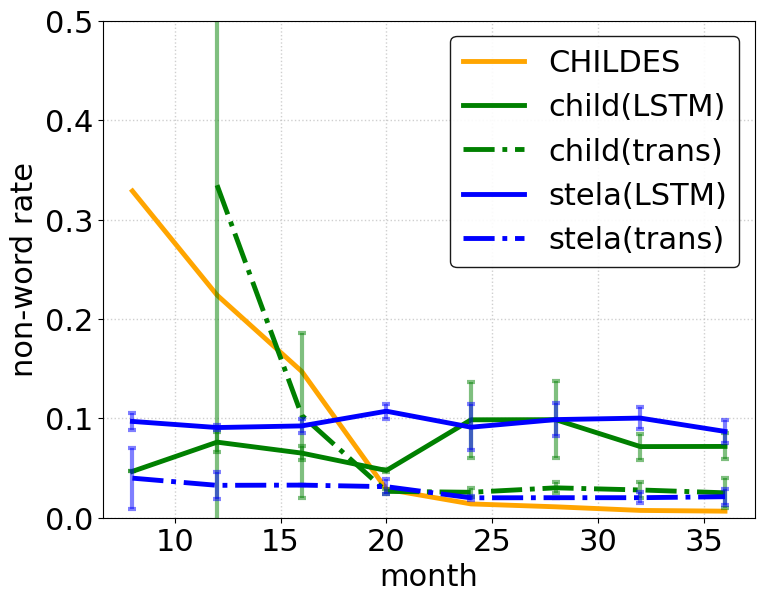

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


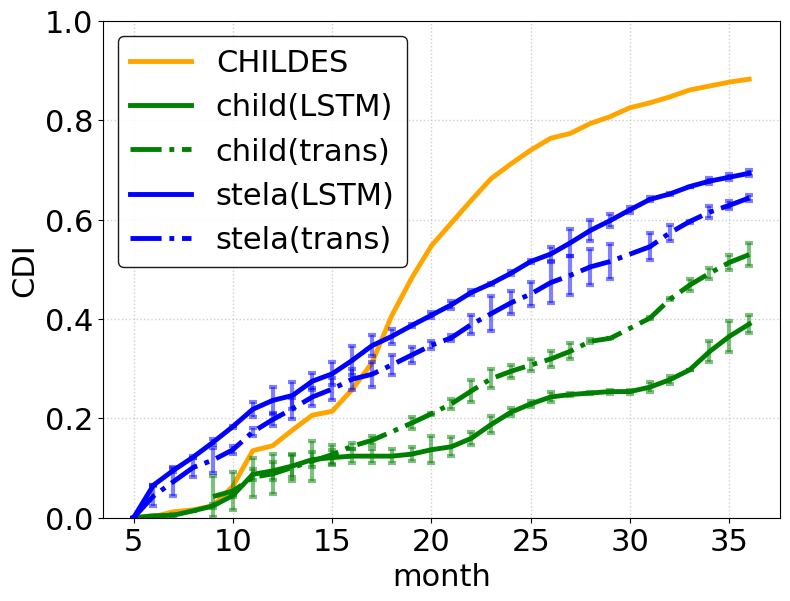

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/type_token_ratio/temp_ttr_500_1_legend.pdf


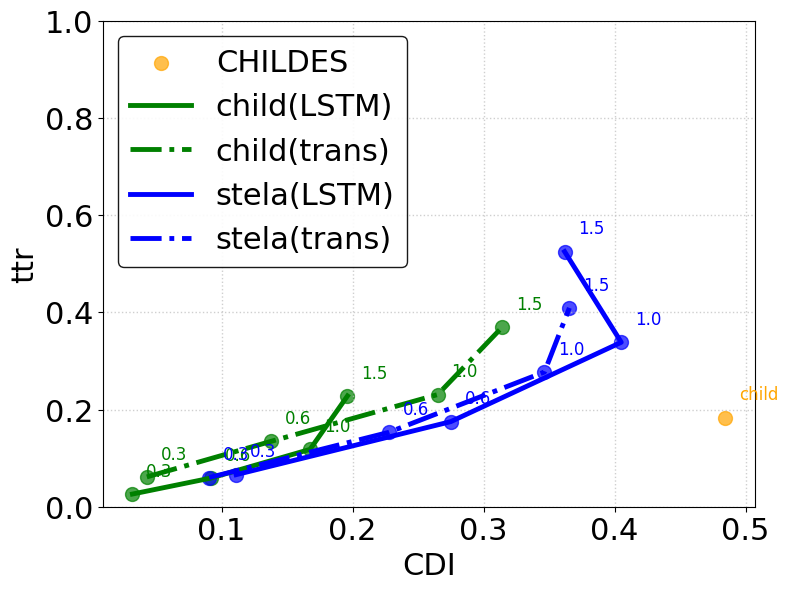

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/rej_type_rate/temp_non-word rate_500_1_legend.pdf


/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


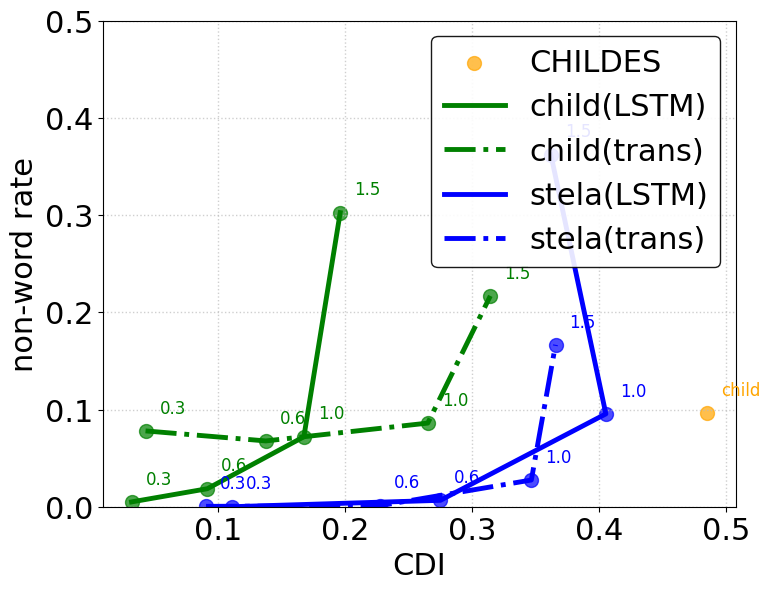

     Unnamed: 0  month  type_token_ratio  rej_type_rate  rej_token_rate  \
512           0      5          0.043714            0.0             0.0   
516           0      5          0.040286            0.0             0.0   
32            0      5          0.022857            0.0             0.0   
528           0      6          0.043714            0.0             0.0   
40            0      6          0.022857            0.0             0.0   
532           0      6          0.040286            0.0             0.0   
544           0      7          0.043714            0.0             0.0   
548           0      7          0.040286            0.0             0.0   
48            0      7          0.022857            0.0             0.0   
560           0      8          0.043714            0.0             0.0   

          CDI  CDI_0  CDI_1  CDI_2     CDI_3     CDI_4     CDI_5  word_num  \
512  0.000000    0.0    0.0    0.0  0.000000  0.000000  0.000000       145   
516  0.000000    0

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


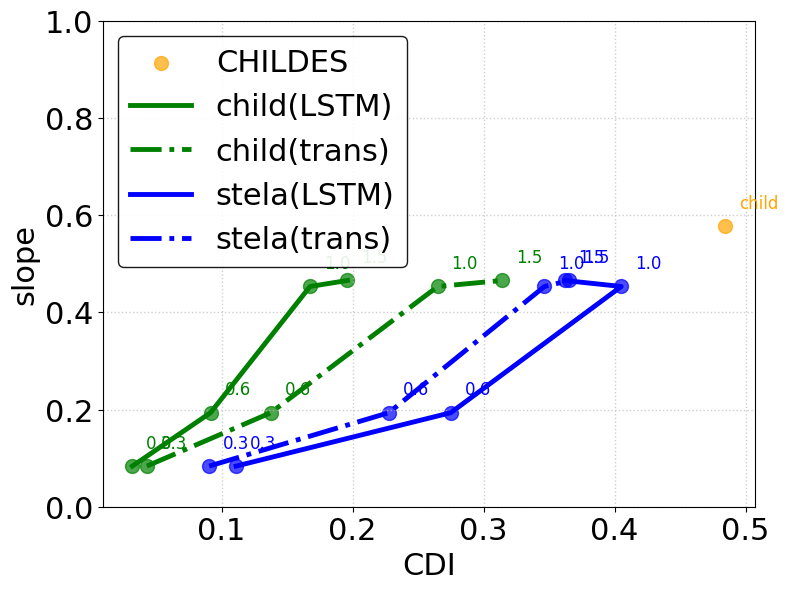

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


##################################################
Current hour 1000; current sampling rate 4


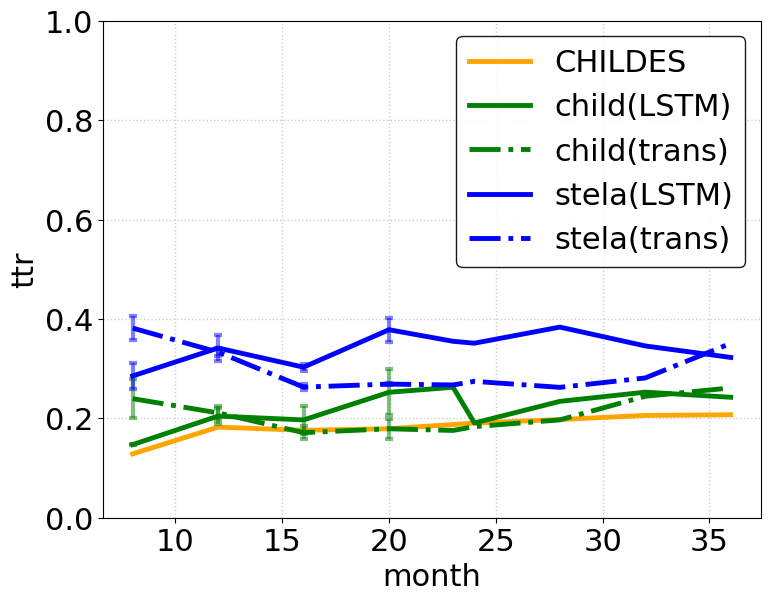

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


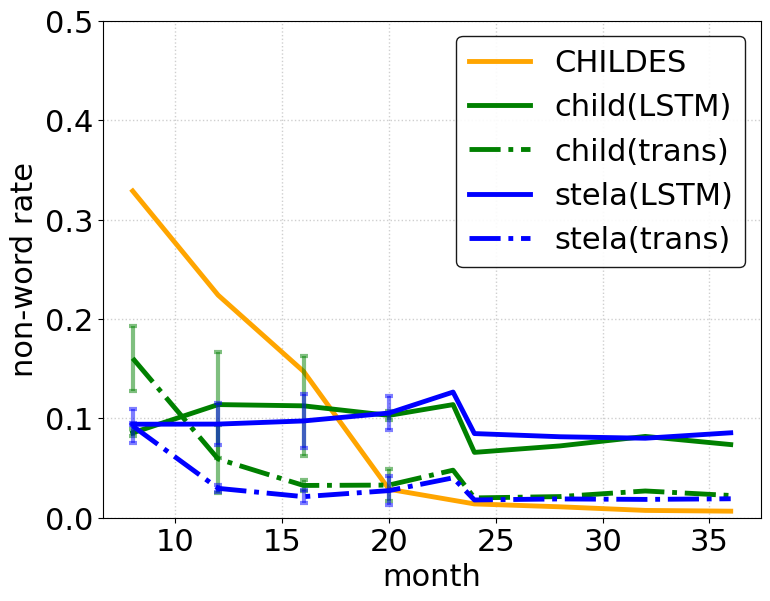

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


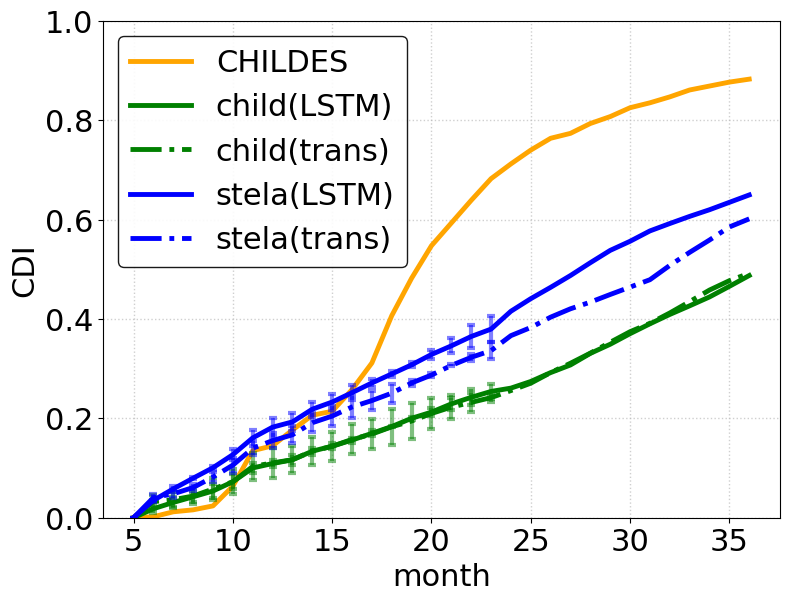

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/type_token_ratio/temp_ttr_1000_4_legend.pdf


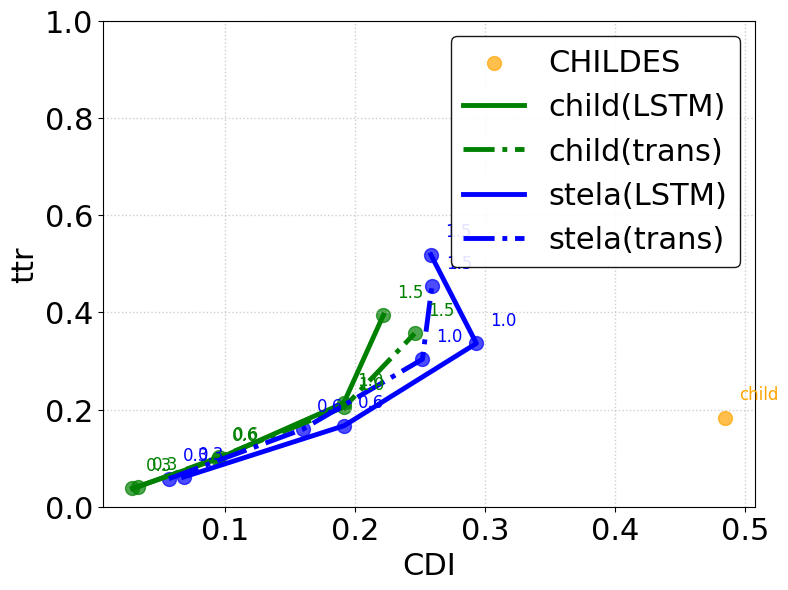

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/rej_type_rate/temp_non-word rate_1000_4_legend.pdf


/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


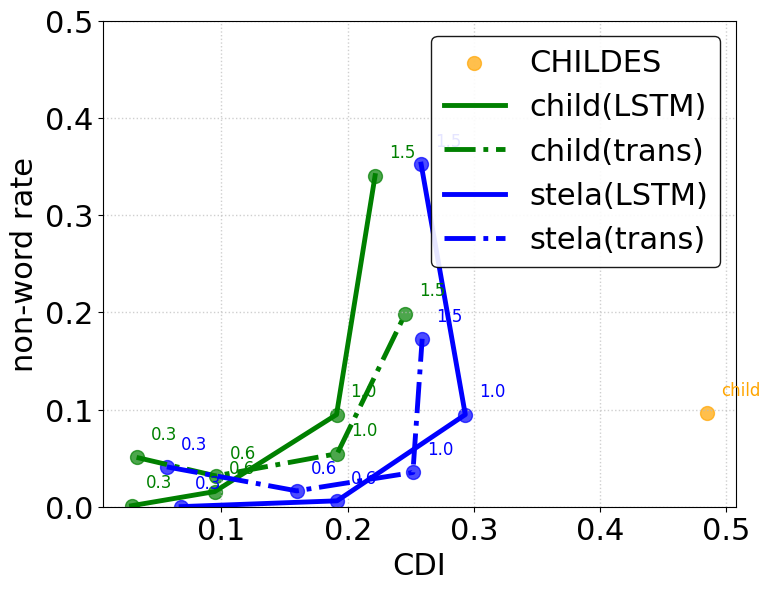

     Unnamed: 0  month  type_token_ratio  rej_type_rate  rej_token_rate  \
32            0      5          0.026857       0.000000           0.000   
36            0      5          0.037143       0.307692           0.014   
440           0      5          0.055143       0.000000           0.000   
444           0      5          0.063714       0.242152           0.020   
52            0      6          0.037143       0.307692           0.014   
48            0      6          0.026857       0.000000           0.000   
460           0      6          0.063714       0.242152           0.020   
456           0      6          0.055143       0.000000           0.000   
472           0      7          0.055143       0.000000           0.000   
476           0      7          0.063714       0.242152           0.020   

          CDI     CDI_0     CDI_1     CDI_2     CDI_3     CDI_4     CDI_5  \
32   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
36   0.000000  0.000

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


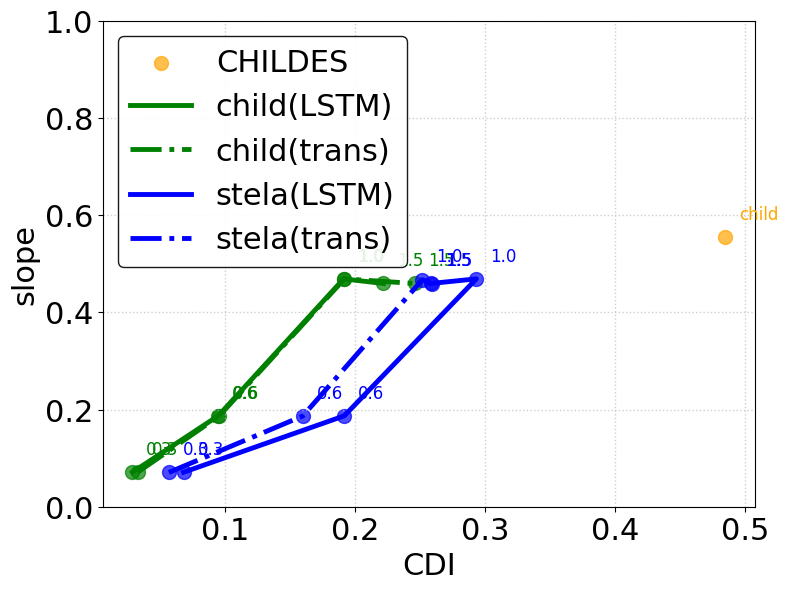

##################################################
Current hour 500; current sampling rate 4


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


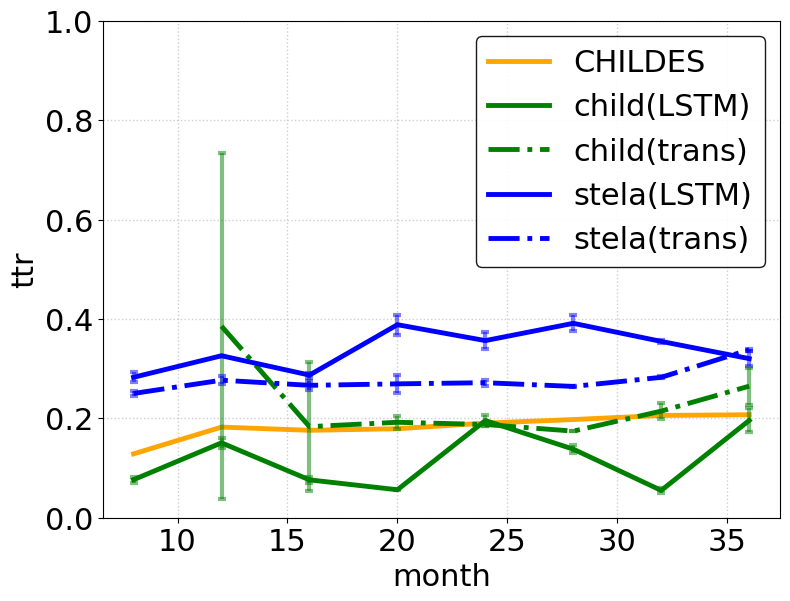

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_1006/3799251012.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


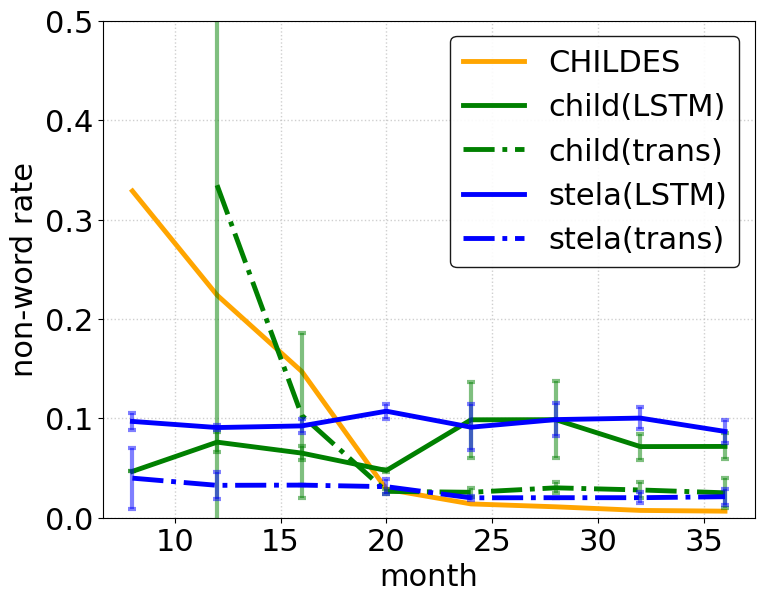

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


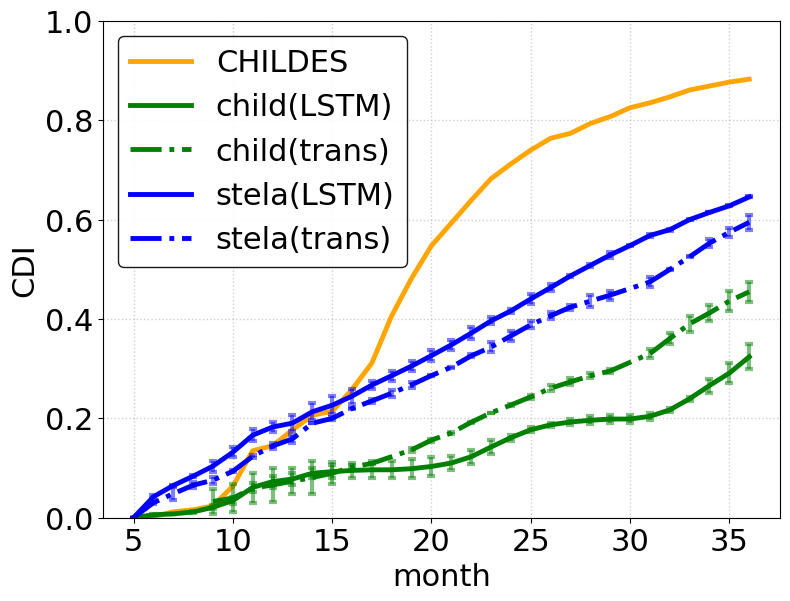

CHILDES(human)
child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/type_token_ratio/temp_ttr_500_4_legend.pdf


/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


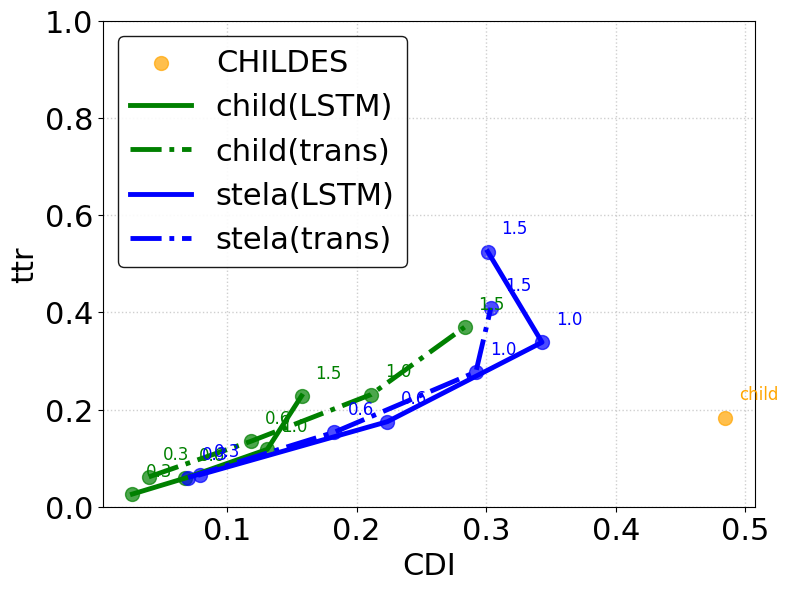

CHILDES(human)


/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


child(LSTM)
child(trans)
stela(LSTM)
stela(trans)
/Users/jliu/workspace/lexical_bencmark/dataset/fig/paper/rej_type_rate/temp_non-word rate_500_4_legend.pdf


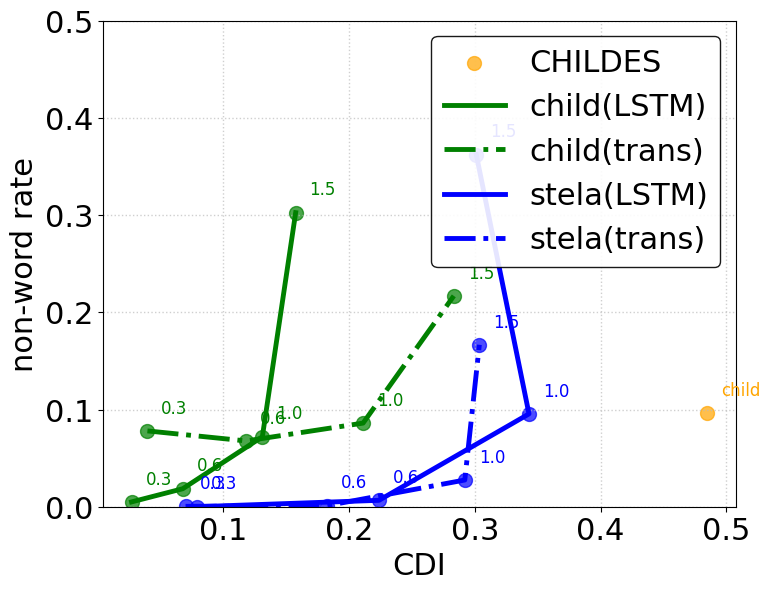

     Unnamed: 0  month  type_token_ratio  rej_type_rate  rej_token_rate  \
512           0      5          0.043714            0.0             0.0   
516           0      5          0.040286            0.0             0.0   
32            0      5          0.022857            0.0             0.0   
528           0      6          0.043714            0.0             0.0   
40            0      6          0.022857            0.0             0.0   
532           0      6          0.040286            0.0             0.0   
544           0      7          0.043714            0.0             0.0   
548           0      7          0.040286            0.0             0.0   
48            0      7          0.022857            0.0             0.0   
560           0      8          0.043714            0.0             0.0   

          CDI  CDI_0  CDI_1     CDI_2     CDI_3     CDI_4     CDI_5  word_num  \
512  0.000000    0.0    0.0  0.000000  0.000000  0.000000  0.000000       145   
516  0.00000

/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1148: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/Users/jliu/anaconda3/envs/genai/lib/python3.12/site-packages/matplotlib/axes/_axes.py:1149: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


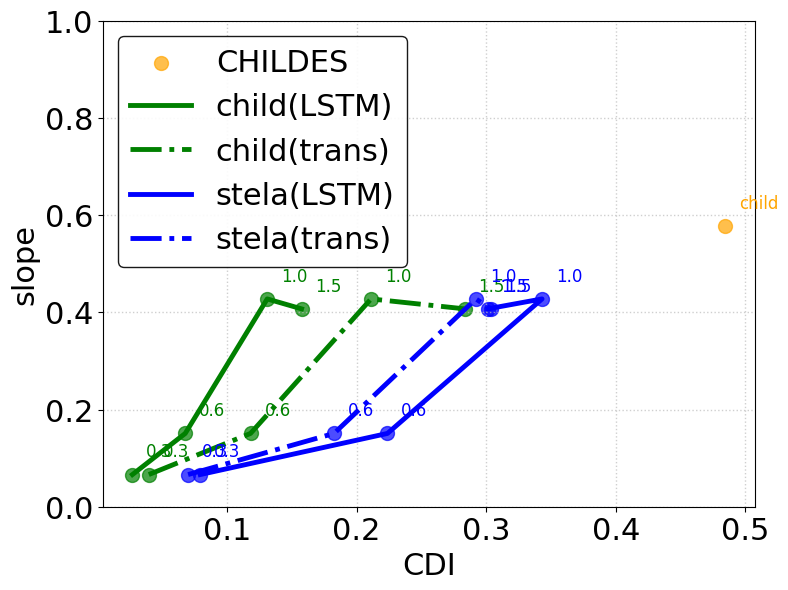

In [43]:
out_path = fig_path / "paper"
metric_dict_temp = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.5], "slope": [0, 1]}
metric_dict_core = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 0.5], "CDI": [0, 1]}
hour_lst = [1000, 500]
sampling_rate_lst = [1, 4]
freq_root = Path(f"{data_root}/word_freq")
for sampling_rate in sampling_rate_lst:
    for hour in hour_lst:
        print("##################################################")
        print(f"Current hour {hour}; current sampling rate {sampling_rate}")
        file_root = Path(f"{data_root}/matched/EN/{sampling_rate}")
        input_path = file_root / f"metric_{hour}_4_3500.csv"
        suffix = f"{hour}_{sampling_rate}"
        compare_metrics(input_path, out_path=out_path, suffix=suffix, metric_dict=metric_dict_core)
        compare_temp(input_path, out_path=out_path, stat_path=data_root / "stat/mean_stat.csv", y_label_dict=y_label_dict, suffix=suffix, metric_dict=metric_dict_temp)

## 2. Sampling ratio and freq

<Figure size 1000x600 with 0 Axes>

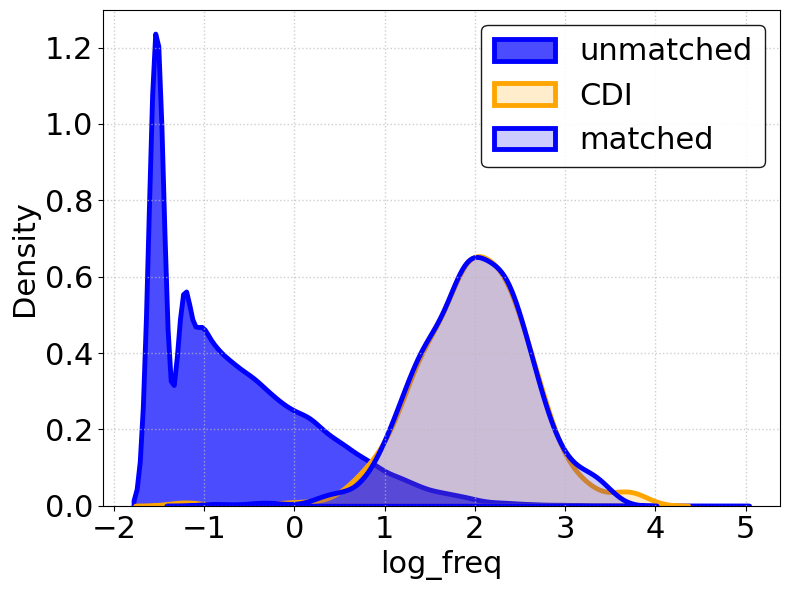

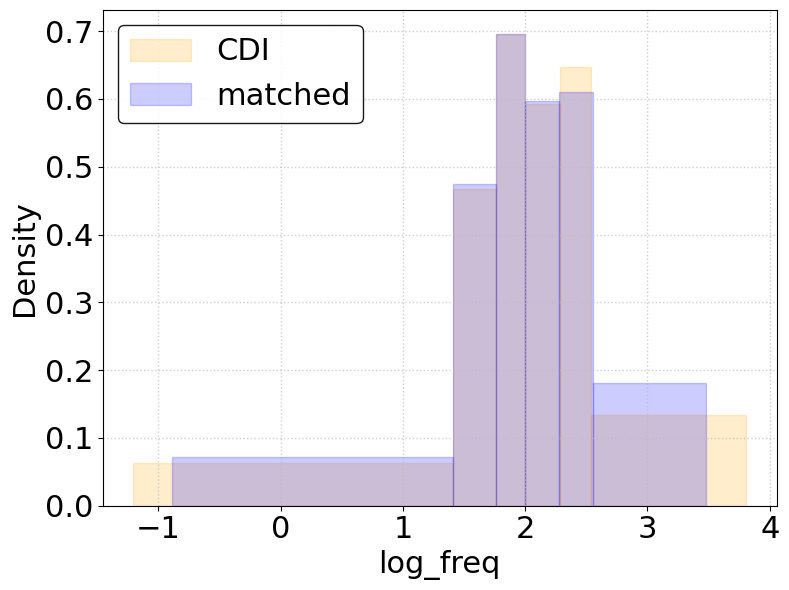

In [147]:
freq_root = Path(f"{data_root}/word_freq")
file_root = Path(f"{data_root}/matched/EN/1")
compare_freq_demo(file_root, freq_root, output_dir=fig_path / "paper")

# Freq effect

In [285]:
def estimate_initial_params(x_data: np.ndarray, y_data: np.ndarray) -> tuple[np.ndarray, tuple[tuple[float, float], ...]]:
    """Estimate initial parameters for faster convergence."""
    mid_idx = len(x_data) // 2
    dx = x_data[mid_idx + 1] - x_data[mid_idx - 1]
    dy = y_data[mid_idx + 1] - y_data[mid_idx - 1]
    initial_slope = dy / dx

    mid_x = x_data[mid_idx]
    mid_y = y_data[mid_idx]
    initial_offset = -initial_slope * mid_x

    bounds = (
        (-10.0, 10.0),  # slope bounds
        (-50.0, 50.0),  # offset bounds
    )
    return np.array([initial_slope, initial_offset]), bounds


def sigmoid(x: np.ndarray, a: float, b: float) -> np.ndarray:
    """Sigmoid function"""
    return 1 / (1 + np.exp(-(a * x + b)))


def linear(x: np.ndarray, a: float, b: float) -> np.ndarray:
    """Linear function"""
    return a * x + b


def get_target_x(x_data: np.ndarray, y_data: np.ndarray, x_fit: np.ndarray, y_fit: np.ndarray, popt: np.ndarray, target_y: float, fit_func: t.Callable) -> float:
    """Get target x value"""
    if max(y_data) < target_y:
        y_fit = fit_func(x_fit, *popt)
        max_iterations = 1000  # Prevent infinite loop
        iterations = 0

        while y_fit[-1] < target_y and iterations < max_iterations:
            x_fit = np.append(x_fit, x_fit[-1] + 1)
            y_fit = np.append(y_fit, fit_func(x_fit[-1], *popt))
            iterations += 1

            if y_fit[-1] >= target_y:
                break

    target_y_index = np.argmin(np.abs(y_fit - target_y))
    return float(x_fit[target_y_index])


def fit_sigmoid(score_df: pd.DataFrame, col_header: str, target_y: float, timeout: float = 10.0, plot_fig: bool = True) -> pd.DataFrame:
    """Fit sigmoid curve of extrapolated exp vocab with timeout"""
    x_data = np.array(score_df["month"].to_list())
    y_data = np.array(score_df[col_header].to_list())

    start_time = time.time()
    fit_type = "sigmoid"

    try:
        p0, bounds = estimate_initial_params(x_data, y_data)

        # Check if we've exceeded timeout
        if time.time() - start_time > timeout:
            raise TimeoutError("Sigmoid initialization exceeded timeout")

        # Fit the sigmoid function
        popt, pcov = curve_fit(sigmoid, x_data, y_data, maxfev=100000, method="trf")

        # Check again for timeout
        if time.time() - start_time > timeout:
            raise TimeoutError("Sigmoid fitting exceeded timeout")

        x_fit = np.linspace(0, max(x_data), 40)
        y_fit = sigmoid(x_fit, *popt)
        fit_func = sigmoid

    except (RuntimeError, TimeoutError) as e:
        print(f"Falling back to linear fit for {col_header} due to: {e!s}")
        popt, pcov = curve_fit(linear, x_data, y_data)
        x_fit = np.linspace(0, max(x_data), 40)
        y_fit = linear(x_fit, *popt)
        fit_func = linear
        fit_type = "linear"

    target_x = get_target_x(x_data, y_data, x_fit, y_fit, popt, target_y, fit_func)

    if plot_fig:
        plt.scatter(x_data, y_data)
        plt.plot(x_fit, y_fit, linewidth=3.5, label=f"{col_header.split('_')[1]} ({fit_type}): {target_x:.2f}")
        plt.legend()
        plt.ylim(0, 1)
        plt.axvline(x=int(target_x), linestyle="dotted")

    header_lst = ["freq", "month", "slope", "weighted_offset", "fit_type"]

    para_frame = pd.DataFrame([[col_header.split("_")[1], target_x, popt[0], popt[1], fit_type]])
    para_frame.columns = header_lst
    return para_frame

In [503]:
def sel_chunk(data):
    df = data[~((data["chunk"] == 0) & (data["dataset"] == "stela") & (data["temp"] == 0.3))]
    df_sel = df[(df["chunk"] == 1) & (df["dataset"] == "stela") & (df["temp"] == 0.3)]
    data = df[df["chunk"] == 0]
    data_sel = pd.concat([df_sel, data])
    return data_sel


def load_freq(col_header_lst: list, file_root: Path) -> dict:
    """Load the median frequency."""
    realistic = pd.read_csv(file_root / "stats_human_realistic_cdi.csv")
    stela = pd.read_csv(file_root / "stats_stela_cdi.csv")
    realistic_freq = realistic[realistic["set"] == "machine"]["median"].to_list()
    human_freq = realistic[realistic["set"] == "human"]["median"].to_list()
    stela_freq = stela[stela["set"] == "machine"]["median"].to_list()
    freq_dict = {}
    n = 0
    while n < len(col_header_lst):
        freq_dict[col_header_lst[n].split("_")[1]] = {
            "CHILDES": human_freq[n],
            "child": realistic_freq[n],
            "stela": stela_freq[n],
        }
        n += 1
    return freq_dict

In [504]:
col_header_lst[1].split()

['CDI_1']

In [412]:
def process_dataframe(df: pd.DataFrame, zero_to_nan: bool = True) -> pd.DataFrame:
    """Process dataframe by optionally converting 0.0 to NaN in freq column.

    Args:
        df: Input dataframe
        zero_to_nan: If True, convert 0.0 to NaN in freq column

    Returns:
        Processed dataframe

    """
    processed_df = df.copy()
    if zero_to_nan:
        processed_df.loc[processed_df["month"] == 0.0, "month"] = np.nan
    return processed_df

In [569]:
def plot_model_comparisons(para_frame: pd.DataFrame, group_lst: list[str], human_dataset: str = "CHILDES", out_path: Path | None = None) -> None:
    """Plot model comparisons with human data using PlotSettings."""
    plt.figure(figsize=(18, 6))
    # Process dataframes
    model_para = process_dataframe(para_frame[para_frame["dataset"] != human_dataset])
    human_para = process_dataframe(para_frame[para_frame["dataset"] == human_dataset])

    # Create color mapping for temperatures
    temps = sorted(model_para["temp"].unique())
    temp_colors = create_color_gradient(len(temps))
    temp_color_map = dict(zip(temps, temp_colors, strict=False))

    # Group data
    para_grouped = model_para.groupby(group_lst)

    # Plot each group
    for group, data_group in para_grouped:
        fig, ax = plt.subplots(figsize=PlotSettings.DEFAULTS["figsize"])

        # Plot human data
        human_valid = human_para.dropna(subset=["freq"])
        ax.plot(
            human_valid["freq"],
            human_valid["month"],
            color=PlotSettings.COLORS.get("CHILDES", "black"),
            linestyle=PlotSettings.LINESTYLES.get("CHILDES", "-"),
            marker="o",
            linewidth=PlotSettings.DEFAULTS["linewidth"],
            markersize=6,
        )

        # Group by temperature and model type
        temp_grouped = data_group.groupby(["temp", "model_type"])

        # Create proxy artists for legend
        temp_legends = []
        model_legends = []

        # Track unique combinations for legend
        plotted_temps = set()
        plotted_models = set()

        for (temp, model_type), para_group in temp_grouped:
            valid_data = para_group.dropna(subset=["freq"])

            # Plot data
            ax.plot(
                valid_data["freq"],
                valid_data["month"],
                color=temp_color_map[temp],  # Use temperature color mapping
                linestyle=PlotSettings.LINESTYLES[model_type],
                marker="x",
                linewidth=PlotSettings.DEFAULTS["linewidth"],
                markersize=5,
            )

            # Add to legend collections (only once per unique value)
            if temp not in plotted_temps:
                temp_legends.append(
                    plt.Line2D(
                        [0],
                        [0],
                        color=temp_color_map[temp],  # Use temperature color mapping
                        label=f"temp={temp}",
                        linewidth=PlotSettings.DEFAULTS["linewidth"],
                    )
                )
                plotted_temps.add(temp)

            if model_type not in plotted_models:
                model_legends.append(
                    plt.Line2D([0], [0], color="gray", label=model_type, linestyle=PlotSettings.LINESTYLES[model_type], linewidth=PlotSettings.DEFAULTS["linewidth"])
                )
                plotted_models.add(model_type)

        # Add separate legends for temperature and model type

        first_legend = ax.legend(handles=temp_legends, bbox_to_anchor=(1.0, 0.95), fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        # ax.add_artist(first_legend)

        # Add model type legend with human reference
        model_legend_handles = [*model_legends, plt.Line2D([0], [0], color=PlotSettings.COLORS["CHILDES"], label="human", marker="o", linestyle="-")]

        second_legend = ax.legend(handles=model_legend_handles, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        # ax.add_artist(second_legend)

        out_path.mkdir(parents=True, exist_ok=True)
        # Configure plot styling
        configure_plot_style(
            x_label="Median log requency per million",
            y_label="Month",
            grid=True,
            out_path=out_path / f"freq_{group[0]}.png",
            show_legend=False,  # Changed to True for better positioning
        )
        # Apply final styling and adjust layout
        PlotSettings.apply_style_to_axis(ax, title=f"Dataset: {group[0]}")
        plt.subplots_adjust(right=0.85)  # Make room for legends


def create_color_gradient(n_shades: int) -> list[str]:
    """Create color gradient from purple through green and blue to dark grey.

    Args:
        n_shades: Number of colors needed

    Returns:
        List of hex color codes for the gradient

    """
    colors = [
        (0.6, 0.0, 0.6),  # Purple
        (0.0, 0.7, 0.3),  # Green
        (0.12, 0.47, 0.71),  # Blue
        (0.2, 0.2, 0.2),  # Dark grey
    ]

    # Positions for smooth transition
    positions = [0, 0.33, 0.67, 1.0]

    custom_cmap = LinearSegmentedColormap.from_list("purple_green_blue_grey", list(zip(positions, colors, strict=False)))

    return [plt.matplotlib.colors.rgb2hex(custom_cmap(i)) for i in np.linspace(0, 1, n_shades)]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 1800x600 with 0 Axes>

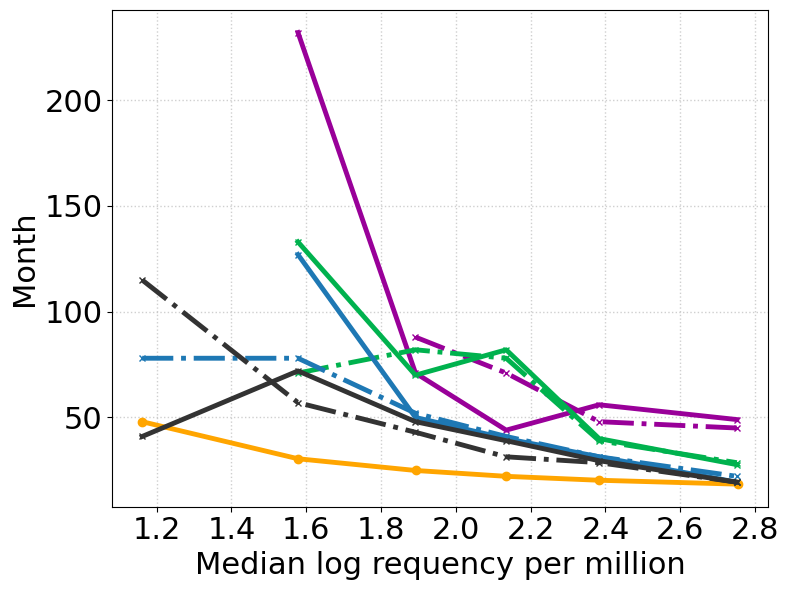

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 640x480 with 0 Axes>

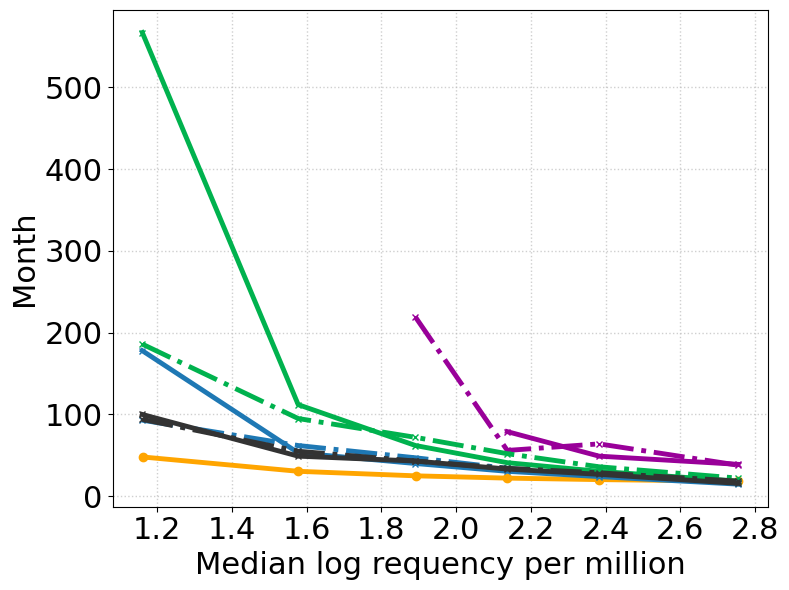

<Figure size 640x480 with 0 Axes>

In [570]:
# loop over different set
col_header_lst = ["CDI_0", "CDI_1", "CDI_2", "CDI_3", "CDI_4", "CDI_5"]
# load and store the results in a dictionary
group_lst = ["dataset", "model_type", "temp", "chunk"]
x_data = score_df["month"].to_list()
x_data = np.array(x_data)
target_y = 0.8
file_root = Path(f"{data_root}/matched/EN/1")
input_path = file_root / "metric_1000_4_3500.csv"

# select chunks from the current results
data = pd.read_csv(input_path)
data_stat = load_freq(col_header_lst, file_root)

sel_data = sel_chunk(data)
data_grouped = sel_data.groupby(group_lst)
para_frame = pd.DataFrame()
for group, data_group in data_grouped:
    for col_header in col_header_lst:
        para = fit_sigmoid(data_group, col_header, target_y, plot_fig=False)
        # append the index to the columns
        n = 0
        while n < len(group):
            para[group_lst[n]] = group[n]
            n += 1
        para["freq"] = data_stat[col_header.split("_")[1]][group[0]]
        para_frame = pd.concat([para_frame, para])
    # plt.title(str(group))
    # plt.show()
# save the fitted stat
para_frame.to_csv(file_root / "sigmoid_para.csv")
plot_model_comparisons(para_frame, group_lst=["dataset"], human_dataset="CHILDES", out_path=fig_path / "paper/freq")

# output table

In [817]:
def load_data(file_path: str | Path) -> pd.DataFrame:
    """Load metrics data from CSV file.

    Args:
        file_path: Path to input CSV file

    Returns:
        Loaded DataFrame

    """
    return pd.read_csv(file_path)


def compute_chunk_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """Compute statistics across chunks for metrics data."""
    # Define columns for metrics and grouping
    metric_columns = ["type_token_ratio", "rej_type_rate", "rej_token_rate", "CDI"]
    group_columns = ["temp", "dataset", "model_type"]

    # First compute mean across months for each chunk
    chunk_means = df.groupby(group_columns + ["chunk"])[metric_columns].mean().reset_index()

    # Then compute statistics across chunks
    final_stats = []

    for (temp, dataset, model), group_df in chunk_means.groupby(group_columns):
        stats_dict = {"temp": temp, "dataset": dataset, "model_type": model}
        score_last = df[(df["temp"] == temp) & (df["dataset"] == dataset) & (df["model_type"] == model) & (df["month"] == 36)]
        # print(score_last)
        # Calculate statistics for each metric
        for metric in metric_columns:
            stats_dict.update(
                {
                    f"{metric}_mean": group_df[metric].mean(),
                    f"{metric}_min": group_df[metric].min(),
                    f"{metric}_max": group_df[metric].max(),
                    f"{metric}_last": score_last[metric].item(),
                }
            )

        final_stats.append(stats_dict)

    # Convert to DataFrame and round results
    results = pd.DataFrame(final_stats).round(4)

    # Sort columns for better readability
    sorted_cols = group_columns + sum([[f"{m}_mean", f"{m}_min", f"{m}_max", f"{m}_last"] for m in metric_columns], [])
    results = results[sorted_cols]

    return results


def save_results(df: pd.DataFrame, output_path: str | Path) -> None:
    """Save results to CSV file.

    Args:
        df: DataFrame with computed statistics
        output_path: Path for output CSV file

    """
    output_path = Path(output_path)
    df.to_csv(output_path, index=False)
    print(f"Results saved to {output_path}")


def analyze_metrics(input_path: str | Path, output_path: str | Path) -> None:
    """Analyze metrics data and save results.

    Args:
        input_path: Path to input CSV file
        output_path: Path for output CSV file

    """
    # Load data
    df = load_data(input_path)

    # Compute statistics
    results = compute_chunk_statistics(df)

    # Save results
    save_results(results, output_path)

    # Print summary
    print("\nResults summary:")
    print(f"Number of groups: {len(results)}")
    print("\nColumns in output:")
    for col in results.columns:
        print(f"- {col}")

In [818]:
sampling_ratio = 4
input_path = data_root / f"CDI_new/CDI_{sampling_ratio}/metric_1000_4.csv"
output_path = Path(data_root / "stat/stat_new.csv")
analyze_metrics(input_path, output_path)

Results saved to /Users/jliu/workspace/lexical_bencmark/dataset/stat/stat_new.csv

Results summary:
Number of groups: 17

Columns in output:
- temp
- dataset
- model_type
- type_token_ratio_mean
- type_token_ratio_min
- type_token_ratio_max
- type_token_ratio_last
- rej_type_rate_mean
- rej_type_rate_min
- rej_type_rate_max
- rej_type_rate_last
- rej_token_rate_mean
- rej_token_rate_min
- rej_token_rate_max
- rej_token_rate_last
- CDI_mean
- CDI_min
- CDI_max
- CDI_last
